In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import accuracy_score, roc_curve, auc, roc_auc_score

In [2]:
# url = https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
# !wget url

In [3]:
df = pd.read_csv('../data/course_lead_scoring_2026.csv')

In [4]:
categorical = list(df.dtypes[df.dtypes == 'str'].index)
df[categorical] = df[categorical].fillna('NA')

numerical = list(df.dtypes[df.dtypes != 'str'].index)
numerical.remove('converted')
df[numerical] = df[numerical].fillna(0)

# Desired target 'converted'. Has the customer converted or not
# df.isnull().sum()

In [5]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# reset the index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# get target
y_train = df_train['converted'].values
y_val = df_val['converted'].values
y_val = df_test['converted'].values


# drop target
del df_train['converted']
del df_val['converted']
del df_test['converted']

In [6]:
'''
Question 1: ROC AUC feature importance
'''

for num in numerical:
    y_score = df_train[num]
    score = roc_auc_score(y_true=y_train, y_score=y_score)
    if score < 0.5:
        score = roc_auc_score(y_true=y_train, y_score=-y_score)
    print(f"{num}: {score}")

# annual_income: 0.6081977776250831
# number_of_courses_viewed: 0.7229894623989618
# interaction_count: 0.7649203047563227
# lead_score: 0.7882254810906102

# Answer: lead_score

annual_income: 0.6081977776250831
number_of_courses_viewed: 0.7229894623989618
interaction_count: 0.7649203047563227
lead_score: 0.7882254810906102


In [7]:
# Accuracy -> Among all transactions, how many did I catch as fraudulent [training + validation + testing datasets]
# precision -> "Among transactions I flag as fraud, how many are actually fraudulent?"
# recall -> "Of all fraudulent transactions, how many did I catch?"

# roc -> returns fpr (false positive rate), tpr(true positive rate),/
#     and several thresholds(e.g t = 0.5, but it gives a huge array take for instance np.linspace(0,1,101)
# auc -> area under curve. It requires fpr and tpr as inputs.(
    # supports these sample outputs with their sample interpretation:
#     0.0: terrible model
#     0.5: random-guessing model
#     0.7: decent model
#     0.9: good model
#     1.0: perfect model
# )
# roc_auc_score -> calculates auc score i.e it first calculates roc(returns fpr, tpr, threshholds) then auc(returns auc score)./
#     It is interpreted as: The probability that your model gives the customer who will cancel a higher score than the customer who won't.

In [55]:
'''
Question 2: Training the model

What's the AUC of this model on the validation dataset? (round to 3 digits)
'''
X_dicts = df_train[numerical + categorical].to_dict(orient="records")

dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(X_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)


X_val_dicts = df_val[numerical + categorical].to_dict(orient="records")
X_val = dv.transform(X_val_dicts)
y_pred = model.predict_proba(X_val)[:,1]

score = roc_auc_score(y_true=y_val, y_score=y_pred)
score

# Answer: 0.508317846896192

0.508317846896192

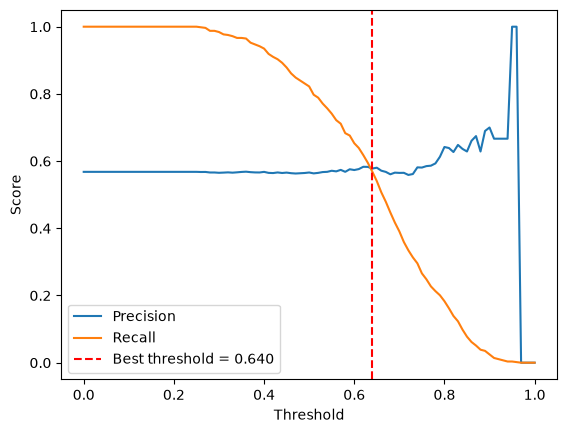

In [95]:
'''
Question 3: Precision and Recall
'''

scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    # p = tp / (tp + fp)
    if (tp + fp) > 0:
        p = tp / (tp + fp)
    else:
        p = 0.0
    r = tp / (tp + fn)
    scores.append((t, tp, fp, fn, tn, p, r))

# place the score in a dataframe before plotting
columns = ['threshold', 'tp', 'fp', 'fn', 'tn', 'precision', 'recall']
df_scores = pd.DataFrame(scores, columns=columns)


# Difference between precision and recall
df_scores['diff'] = abs(df_scores['precision'] - df_scores['recall'])
# Ignore thresholds where both precision and recall are zero
valid_scores = df_scores[
    ~((df_scores['precision'] == 0) & (df_scores['recall'] == 0))
]
# Find threshold where precision and recall are closest
best = valid_scores.loc[valid_scores['diff'].idxmin()]



plt.plot(df_scores.threshold, df_scores['precision'], label='Precision')
plt.plot(df_scores.threshold, df_scores['recall'], label='Recall')

# Mark the closest point
# plt.scatter(best['threshold'], best['precision'], color='red', zorder=5)

plt.axvline(best['threshold'], color='red', linestyle='--', label=f"Best threshold = {best['threshold']:.3f}")


plt.xlabel("Threshold")
plt.ylabel("Score")

plt.legend()
plt.show()

# Answer: Best threshold = 0.640

In [106]:
'''
Question 4: F1 score
'''
# f1 = 2 * ((p * r)/(p + r))

df_scores["F1"] = 2 * ((df_scores['precision'] * df_scores['recall'])/(df_scores['precision'] + df_scores['recall']))

valid_scores = df_scores[~df_scores['threshold'].isin([0,1])]
ans = valid_scores.loc[valid_scores['F1'].idxmax()]
# ans.threshold



In [105]:
'''
    Drilling down on the F1 score of question 4's possible answers
    because the dataframe option was not producing an absolute answer, because F1 score for all thresholds from 0.01 to 0.25 is the same
'''

for t in [0.21, 0.41, 0.61, 0.81]:
    predict_positive = y_pred >= t
    actual_positive = y_val == 1
    actual_negative = y_val == 0
    predict_negative = y_pred < t

    tp = (predict_positive & actual_positive).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    print(
        f"Threshold: {t:.2f} | "
        # f"TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn} | "
        # f"Precision: {precision:.3f} | "
        # f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

# answer: 0.21

Threshold: 0.21 | F1: 0.724
Threshold: 0.41 | F1: 0.700
Threshold: 0.61 | F1: 0.606
Threshold: 0.81 | F1: 0.258


In [122]:
'''
    Question 5: 5-Fold CV
'''

# model training function
def train(df_train, y_train):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

# model predicting function
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

# K_Fold iteration
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []
for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))
# Answer: 0.007

0.732 +- 0.007


In [124]:
# model training function
def train(df_train, y_train, c):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

# model predicting function
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [125]:
'''
    Question 6: Hyperparameter Tuning
'''
C = [0.000001, 0.001, 1]

for c in C:
    # K_Fold iteration
    kfold = KFold(n_splits=5, shuffle=True, random_state=1)
    
    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]
    
        y_train = df_train.converted.values
        y_val = df_val.converted.values
    
        dv, model = train(df_train, y_train, c)
        y_pred = predict(df_val, dv, model)
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    
    print('%f %.3f +- %.3f' % (c, np.mean(scores), np.std(scores)))

# Answer: 0.001

0.000001 0.617 +- 0.019
0.001000 0.749 +- 0.010
1.000000 0.732 +- 0.007
